<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/12_analise_milho_economica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Configuração e carregamento dos dados

In [10]:
!pip install -q geobr unidecode

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import geobr
import unidecode
import matplotlib.ticker as mticker

BASE_URL = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main/"

def carregar(nome_arquivo, **kwargs):
    """Lê um CSV diretamente do GitHub (raw) para um DataFrame pandas."""
    return pd.read_csv(BASE_URL + nome_arquivo, **kwargs)

In [2]:
# Carregamento de todos os resultados relevantes gerados pelos notebooks 05, 09 e 10 do repositório.

# Desempenho do modelo Extra Trees na predição de produtividade (Notebook 05)
resultados_inferencia = carregar("resultados_inferencia.csv")

# Produtividade prevista por município, ano-safra e data de semeadura (Notebook 05/09)
previsoes = carregar("previsoes_oeste_pr.csv")

# Risco climático (ISNA) por combinação município x data de semeadura (Notebook 09, Seção 3.4.1)
risco_clima = carregar("risco_climatico_oeste_pr.csv")

# Risco econômico (margem) por combinação (Notebook 09, Seção 3.4.2)
risco_economico = carregar("risco_economico_oeste_pr.csv")

# Matriz integrada com os três eixos + escore ordinal por tercis (Notebook 10, Seção 3.4.3)
matriz_topsis = carregar("matriz_topsis_oeste_pr.csv")

# Recomendação final — abordagem ordinal por tercis (Eq. 7)
melhor_data_ordinal = carregar("melhor_data_semeadura_integrada.csv")

# Recomendação final — abordagem TOPSIS (Eq. 16)
melhor_data_topsis = carregar("melhor_data_semeadura_topsis.csv")

# Padronização do formato da data de semeadura: os valores originais vêm com uma barra
# sobrando no final (ex.: "05/02/"), resquício da exportação. Removemos aqui para leitura correta.
for df in [risco_clima, risco_economico, matriz_topsis, melhor_data_ordinal,
           melhor_data_topsis, previsoes]:
    df["data_semeadura"] = df["data_semeadura"].str.rstrip("/")

print("risco_climatico_oeste_pr.csv  :", risco_clima.shape)
print("risco_economico_oeste_pr.csv  :", risco_economico.shape)
print("matriz_topsis_oeste_pr.csv    :", matriz_topsis.shape)
print("melhor_data (ordinal)         :", melhor_data_ordinal.shape)
print("melhor_data (TOPSIS)          :", melhor_data_topsis.shape)
print("previsoes_oeste_pr.csv        :", previsoes.shape)
print("resultados_inferencia.csv     :", resultados_inferencia.shape)
print()
print("Municípios avaliados:", matriz_topsis['municipio'].nunique())
print("Datas de semeadura avaliadas:", sorted(matriz_topsis['data_semeadura'].unique()))

risco_climatico_oeste_pr.csv  : (300, 12)
risco_economico_oeste_pr.csv  : (300, 6)
matriz_topsis_oeste_pr.csv    : (300, 25)
melhor_data (ordinal)         : (50, 7)
melhor_data (TOPSIS)          : (50, 6)
previsoes_oeste_pr.csv        : (8100, 4)
resultados_inferencia.csv     : (24, 9)

Municípios avaliados: 50
Datas de semeadura avaliadas: ['05/02', '05/03', '15/02', '15/03', '25/02', '25/03']


## 2. Gráfico dos custos e preços deflacionados e real

In [3]:
custoderal = carregar("custo_deral_milho_safrinha.csv")
preco = carregar("precos_milho_pr.csv")

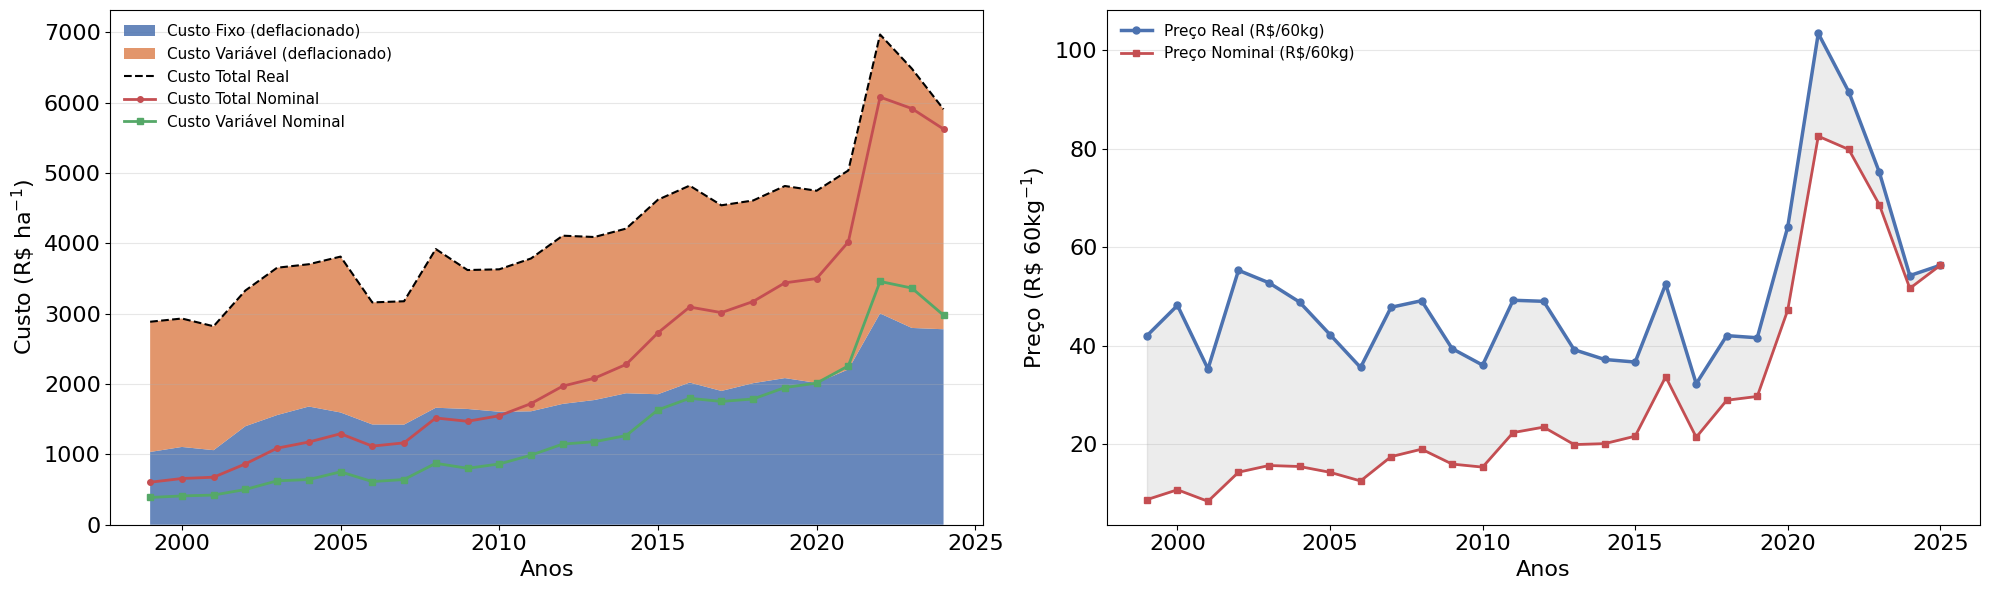

In [4]:

# Ordenar por ano
df_custo = custoderal.sort_values('ano')
df_preco = preco.sort_values('ano')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# ========== PAINEL ESQUERDO: CUSTO ==========
ax1.stackplot(
    df_custo['ano'],
    df_custo['custo_fixo_real'],
    df_custo['custo_rs_ha_variavel_real'],
    labels=['Custo Fixo (deflacionado)', 'Custo Variável (deflacionado)'],
    colors=['#4C72B0', '#DD8452'],
    alpha=0.85
)

ax1.plot(
    df_custo['ano'],
    df_custo['custo_rs_ha_total_real'],
    color='black', linewidth=1.5, linestyle='--',
    label='Custo Total Real'
)

ax1.plot(
    df_custo['ano'],
    df_custo['custo_rs_ha_total_nominal'],
    color='#C44E52', linewidth=2, linestyle='-', marker='o', markersize=4,
    label='Custo Total Nominal'
)

ax1.plot(
    df_custo['ano'],
    df_custo['custo_rs_ha_variavel_nominal'],
    color='#55A868', linewidth=2, linestyle='-', marker='s', markersize=4,
    label='Custo Variável Nominal'
)

ax1.set_xlabel('Anos', fontsize=16)
ax1.set_ylabel(r'Custo (R\$ ha$^{-1}$)', fontsize=16)
ax1.legend(loc='upper left', frameon=False, ncol=1, fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)

# ========== PAINEL DIREITO: PREÇO ==========
ax2.plot(
    df_preco['ano'],
    df_preco['preco_rs_60kg_real'],
    color='#4C72B0', linewidth=2.5, marker='o', markersize=5,
    label='Preço Real (R$/60kg)'
)

ax2.plot(
    df_preco['ano'],
    df_preco['preco_rs_60kg_nominal'],
    color='#C44E52', linewidth=2, linestyle='-', marker='s', markersize=4,
    label='Preço Nominal (R$/60kg)'
)

ax2.fill_between(
    df_preco['ano'],
    df_preco['preco_rs_60kg_real'],
    df_preco['preco_rs_60kg_nominal'],
    color='gray', alpha=0.15
)

ax2.set_xlabel('Anos', fontsize=16)
ax2.set_ylabel(r'Preço (R\$ 60kg$^{-1}$)', fontsize=16)
ax2.legend(loc='upper left', frameon=False, fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()

## 2. Risco climático

In [5]:
risco_clima

,municipio,data_semeadura,isna_medio,isna_desvio,n_anos,freq_evento_adverso,freq_deficit_faseI,freq_deficit_faseIII,freq_frio_floracao,freq_geada,freq_excesso_faseIV,risco_climatico
0,Anahy,05/02,0.749378,0.116693,27,0.444444,0.148148,0.370370,0.407407,0.000000,0.222222,Inapto (risco > 40%)
1,Anahy,05/03,0.709596,0.111680,27,0.370370,0.222222,0.185185,1.000000,0.000000,0.444444,Risco climático 40%
2,Anahy,15/02,0.735781,0.103092,27,0.296296,0.037037,0.259259,0.740741,0.000000,0.259259,Risco climático 30%
3,Anahy,15/03,0.716376,0.108367,27,0.481481,0.296296,0.259259,1.000000,0.037037,0.518519,Inapto (risco > 40%)
4,Anahy,25/02,0.710012,0.108804,27,0.333333,0.111111,0.259259,0.925926,0.000000,0.370370,Risco climático 40%
...,...,...,...,...,...,...,...,...,...,...,...,...
295,Vera Cruz do Oeste,05/03,0.726441,0.095579,27,0.370370,0.296296,0.148148,1.000000,0.000000,0.518519,Risco climático 40%
296,Vera Cruz do Oeste,15/02,0.727763,0.096866,27,0.296296,0.111111,0.222222,0.851852,0.000000,0.370370,Risco climático 30%
297,Vera Cruz do Oeste,15/03,0.735616,0.098513,27,0.555556,0.444444,0.111111,1.000000,0.037037,0.481481,Inapto (risco > 40%)
298,Vera Cruz do Oeste,25/02,0.719459,0.097998,27,0.296296,0.222222,0.148148,0.962963,0.000000,0.407407,Risco climático 30%


/tmp/ipykernel_2839/3638421698.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(dados_boxplot, labels=ordem_datas, patch_artist=True)


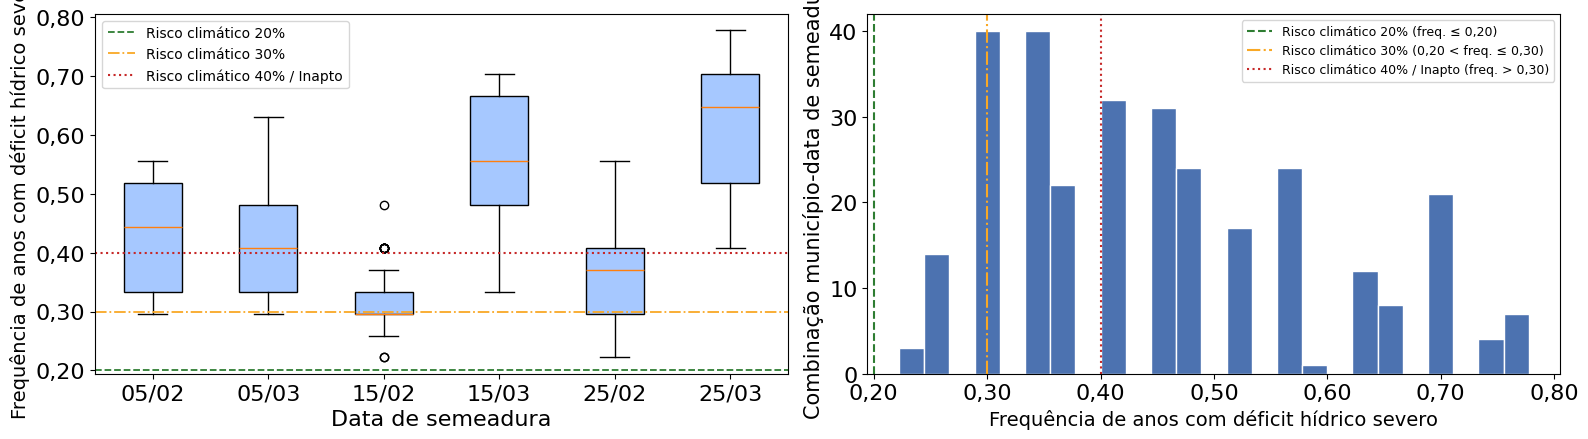

risco_climatico
Inapto (risco > 40%)    181
Risco climático 40%      62
Risco climático 30%      57
Name: count, dtype: int64


In [8]:
def formatar_virgula(x, pos):
    return f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

ordem_datas = sorted(risco_clima["data_semeadura"].unique())

# Limiares oficiais do ZARC (Portaria SPA/MAPA nº 329/2026) sobre a frequência de anos com
# déficit hídrico severo — quanto MAIOR a frequência, PIOR (inverso do ISNA médio antigo).
LIMIAR_20 = 0.20
LIMIAR_30 = 0.30
LIMIAR_40 = 0.40
COR_20 = "#2E7D32"   # verde — fronteira do risco climático 20% (melhor)
COR_30 = "#F9A825"   # âmbar — fronteira do risco climático 30%
COR_40 = "#C62828"   # vermelho — fronteira do risco climático 40% / inapto

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))

# ========== PAINEL ESQUERDO: BOXPLOT ==========
dados_boxplot = [risco_clima.loc[risco_clima["data_semeadura"] == d, "freq_evento_adverso"] for d in ordem_datas]
bp = ax1.boxplot(dados_boxplot, labels=ordem_datas, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#a6c8ff")

ax1.axhline(LIMIAR_20, color=COR_20, linestyle="--", linewidth=1.3, label="Risco climático 20%")
ax1.axhline(LIMIAR_30, color=COR_30, linestyle="-.", linewidth=1.3, label="Risco climático 30%")
ax1.axhline(LIMIAR_40, color=COR_40, linestyle=":", linewidth=1.5, label="Risco climático 40% / Inapto")
ax1.set_xlabel("Data de semeadura", fontsize=16)
ax1.set_ylabel("Frequência de anos com déficit hídrico severo", fontsize=14)
#ax1.set_title("Frequência de déficit hídrico severo por data de semeadura, entre os 50 municípios do Oeste do Paraná")
ax1.legend()
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

# ========== PAINEL DIREITO: HISTOGRAMA ==========
ax2.hist(risco_clima["freq_evento_adverso"], bins=25, color="#4C72B0", edgecolor="white")

ax2.axvline(LIMIAR_20, color=COR_20, linestyle="--", label="Risco climático 20% (freq. ≤ 0,20)")
ax2.axvline(LIMIAR_30, color=COR_30, linestyle="-.", label="Risco climático 30% (0,20 < freq. ≤ 0,30)")
ax2.axvline(LIMIAR_40, color=COR_40, linestyle=":", label="Risco climático 40% / Inapto (freq. > 0,30)")

ax2.set_xlabel("Frequência de anos com déficit hídrico severo", fontsize=14)
ax2.set_ylabel("Combinação município-data de semeadura", fontsize=15)
#ax2.set_title("Distribuição da frequência de déficit hídrico severo entre as 300 combinações avaliadas")
ax2.legend(loc='upper right', fontsize=9)
ax2.tick_params(axis='x', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_virgula))

plt.tight_layout()
plt.show()

# Contagem de combinações por classe de risco climático
print(risco_clima["risco_climatico"].value_counts())

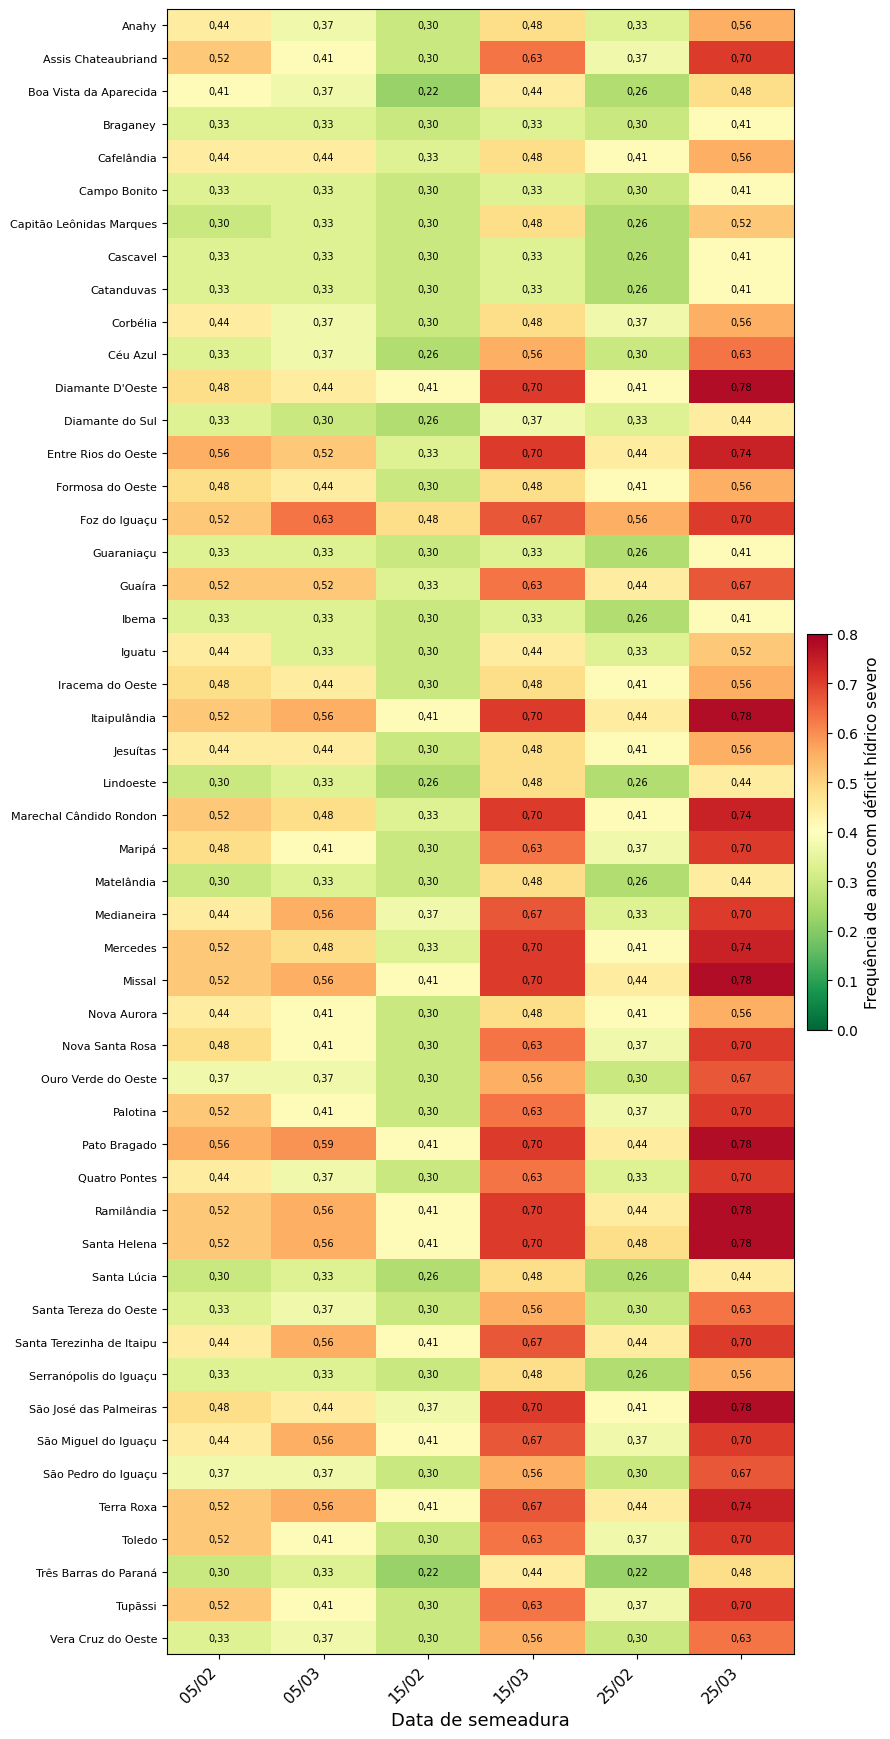

In [13]:
SEM = ['05/02', '05/03', '15/02', '15/03', '25/02', '25/03']
pivot_risco_clima = risco_clima.pivot(index="municipio", columns="data_semeadura", values="freq_evento_adverso")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_risco_clima))))
im = ax.imshow(pivot_risco_clima, cmap="RdYlGn_r", vmin=0, vmax=0.8, aspect="auto")

ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right", fontsize=11)
ax.set_yticks(range(len(pivot_risco_clima.index)))
ax.set_yticklabels(pivot_risco_clima.index, fontsize=8)

for i in range(pivot_risco_clima.shape[0]):
    for j in range(pivot_risco_clima.shape[1]):
        v = pivot_risco_clima.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, formatar_virgula(v, None), ha="center", va="center", fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Frequência de anos com déficit hídrico severo", fontsize=11)

ax.set_xlabel("Data de semeadura", fontsize=13)
#ax.set_title("Frequência de déficit hídrico severo por município × data de semeadura", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Risco economico

In [15]:
risco_economico

,municipio,data_semeadura,n_anos,pct_anos_cobre_custo,margem_media_rs_ha,risco_economico
0,Anahy,05/02,26,7.7,-874.341029,Viabilidade intermediária
1,Anahy,05/03,26,7.7,-871.184144,Mais viável
2,Anahy,15/02,26,3.8,-885.637017,Viabilidade intermediária
3,Anahy,15/03,26,3.8,-874.048059,Viabilidade intermediária
4,Anahy,25/02,26,3.8,-874.832799,Viabilidade intermediária
...,...,...,...,...,...,...
295,Vera Cruz do Oeste,05/03,26,7.7,-853.936316,Mais viável
296,Vera Cruz do Oeste,15/02,26,7.7,-890.255744,Viabilidade intermediária
297,Vera Cruz do Oeste,15/03,26,7.7,-871.658598,Mais viável
298,Vera Cruz do Oeste,25/02,26,7.7,-861.987501,Mais viável


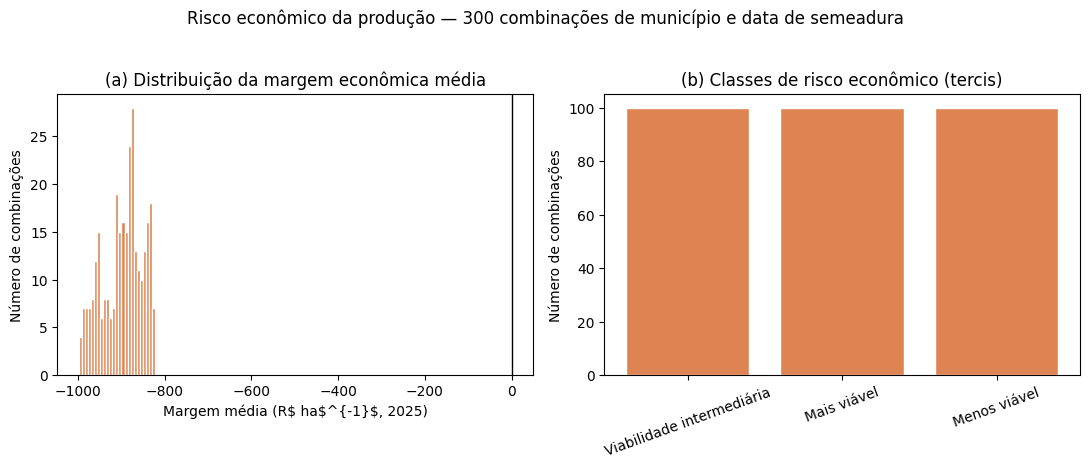

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(risco_economico["margem_media_rs_ha"], bins=25, color="#DD8452", edgecolor="white")
axes[0].axvline(0, color="black", linestyle="-", linewidth=1)
axes[0].set_xlabel("Margem média (R$ ha$^{-1}$, 2025)")
axes[0].set_ylabel("Número de combinações")
axes[0].set_title("(a) Distribuição da margem econômica média")

contagem_risco = risco_economico["risco_economico"].value_counts()
axes[1].bar(contagem_risco.index, contagem_risco.values, color="#DD8452", edgecolor="white")
axes[1].set_ylabel("Número de combinações")
axes[1].set_title("(b) Classes de risco econômico (tercis)")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Risco econômico da produção — 300 combinações de município e data de semeadura", y=1.03)
fig.tight_layout()
plt.show()